### **Bayesian Networks in Titanic — V2**

**Goal:** Maximize BN accuracy by reducing CPT sparsity and keeping strong predictors.

**Improvements over V1:**
- Keep Sex (strongest predictor, only 2 categories = dense CPTs)
- Keep Title for auxiliary signal (Title→Sex, Title→Age edges)
- Coarser binning: Age→2 bins, Fare→2 bins
- Drop Embarked (lowest MI)
- Tree-Augmented Naive Bayes (TAN) structure
- Sweep `equivalent_sample_size` for BDeu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import warnings

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import (
    MaximumLikelihoodEstimator,
    BayesianEstimator,
    HillClimbSearch,
    TreeSearch,
    BIC,
)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    mutual_info_score,
    confusion_matrix,
    classification_report,
)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

#### **1. Load & Preprocess**

Key changes vs V1:
- **Keep Sex** — strongest predictor (MI=0.15), only 2 categories = very dense CPTs
- **Keep Title** — auxiliary signal for Age/Sex relationships
- **Age**: 2 bins (Child/Adult) instead of 4
- **Fare**: 2 bins (Low/High) instead of 3
- **Drop Embarked**: lowest MI with Survived (0.014)

In [2]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
raw_df = pd.read_csv(url)

df = raw_df.copy()

# 1. FamilySize = SibSp + Parch (binned: Alone / Small / Large)
df["FamilySize"] = df["SibSp"] + df["Parch"]
df["FamilySize"] = pd.cut(
    df["FamilySize"],
    bins=[-1, 0, 3, 20],
    labels=["Alone", "Small", "Large"],
)

# 2. Title from Name
df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
title_map = {"Mr": "Mr", "Miss": "Miss", "Mrs": "Mrs", "Master": "Master"}
df["Title"] = df["Title"].map(lambda t: title_map.get(t, "Rare"))

# 3. Age: 2 bins (coarser = denser CPT)
df["Age"] = pd.cut(
    df["Age"].fillna(df["Age"].median()),
    bins=[0, 15, 120],
    labels=["Child", "Adult"],
)

# 4. Fare: 2 bins (median split)
df["Fare"] = pd.qcut(df["Fare"], q=2, labels=["Low", "High"])

# 5. Keep Sex + Title + other features, drop Embarked
cols = ["Survived", "Pclass", "Sex", "Age", "Fare", "FamilySize", "Title"]
df = df[cols].copy()
df.dropna(inplace=True)

# Convert all to string for pgmpy
for col in df.columns:
    df[col] = df[col].astype(str)

print(f"Dataset shape: {df.shape}")
print(f"\nCardinalities:")
for col in df.columns:
    print(f"  {col}: {df[col].nunique()} — {sorted(df[col].unique())}")
df.head()

Dataset shape: (891, 7)

Cardinalities:
  Survived: 2 — ['0', '1']
  Pclass: 3 — ['1', '2', '3']
  Sex: 2 — ['female', 'male']
  Age: 2 — ['Adult', 'Child']
  Fare: 2 — ['High', 'Low']
  FamilySize: 3 — ['Alone', 'Large', 'Small']
  Title: 5 — ['Master', 'Miss', 'Mr', 'Mrs', 'Rare']


,Survived,Pclass,Sex,Age,Fare,FamilySize,Title
0,0,3,male,Adult,Low,Small,Mr
1,1,1,female,Adult,High,Small,Mrs
2,1,3,female,Adult,Low,Alone,Miss
3,1,1,female,Adult,High,Small,Mrs
4,0,3,male,Adult,Low,Alone,Mr


In [3]:
# CPT size analysis: how many combinations for Survived's parents?
# V1: Sex(2) x Pclass(3) x Age(4) x FamilySize(3) x Fare(3) = 216
# V2: Sex(2) x Pclass(3) x FamilySize(3) = 18  (minimal, dense)
# V2 extended: Sex(2) x Pclass(3) x FamilySize(3) x Fare(2) = 36

v1_cpt = 2 * 3 * 4 * 3 * 3
v2_cpt = 2 * 3 * 3 * 2
v2_min = 2 * 3 * 3
print(f"V1 Survived CPT cells: {v1_cpt}")
print(f"V2 Survived CPT cells: {v2_cpt} (with Fare)")
print(f"V2 minimal CPT cells:  {v2_min} (without Fare)")
print(f"Reduction: {v1_cpt / v2_cpt:.1f}x fewer cells")
print(f"~{len(df)*0.8 / v2_cpt:.0f} samples per CPT cell (train)")

V1 Survived CPT cells: 216
V2 Survived CPT cells: 36 (with Fare)
V2 minimal CPT cells:  18 (without Fare)
Reduction: 6.0x fewer cells
~20 samples per CPT cell (train)


#### **2. Train / Test Split**

In [4]:
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=RANDOM_STATE, stratify=df["Survived"]
)

# IMPORTANT: reset index so pgmpy predict() aligns correctly.
# pgmpy's predict returns predictions with a new sequential index,
# not the original DataFrame index. Without reset, accuracy_score
# compares misaligned rows.
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

y_test = test_df["Survived"].astype(int)
X_test_bn = test_df.drop(columns=["Survived"])

print(f"Train: {len(train_df)}, Test: {len(test_df)}")
print(f"Survival rate — Train: {train_df['Survived'].astype(int).mean():.2%}, Test: {y_test.mean():.2%}")

Train: 712, Test: 179
Survival rate — Train: 38.34%, Test: 38.55%


#### **3. Mutual Information Analysis**

Sex should remain the strongest single predictor. Title adds signal beyond Sex.

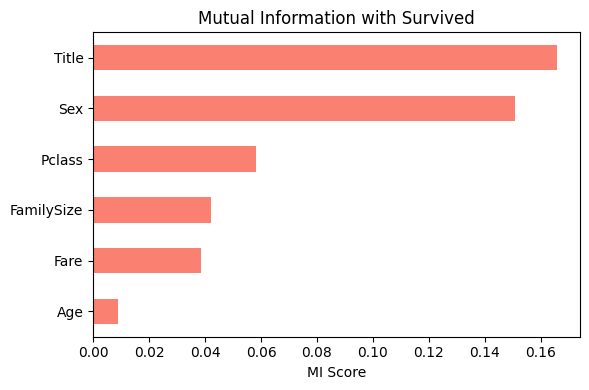

Title         0.165706
Sex           0.150870
Pclass        0.058107
FamilySize    0.042140
Fare          0.038407
Age           0.008967
dtype: float64


In [5]:
mi_scores = {
    col: mutual_info_score(df["Survived"], df[col])
    for col in df.columns if col != "Survived"
}
mi_series = pd.Series(mi_scores).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(6, 4))
mi_series.plot(kind="barh", color="salmon", ax=ax)
ax.set_title("Mutual Information with Survived")
ax.set_xlabel("MI Score")
plt.tight_layout()
plt.show()

print(mi_series.sort_values(ascending=False))

#### **4. Expert DAG (V2 — Sex as primary, Title as auxiliary)**

Key design: **Sex stays as direct Survived parent** (2 categories = dense CPT).
Title provides auxiliary edges (Title→Sex, Title→Age) but is NOT a direct parent of Survived.

Survived parents: Sex, Pclass, FamilySize, Fare
- Sex(2) × Pclass(3) × FamilySize(3) × Fare(2) = **36 cells** with ~710 train rows = ~20 per cell

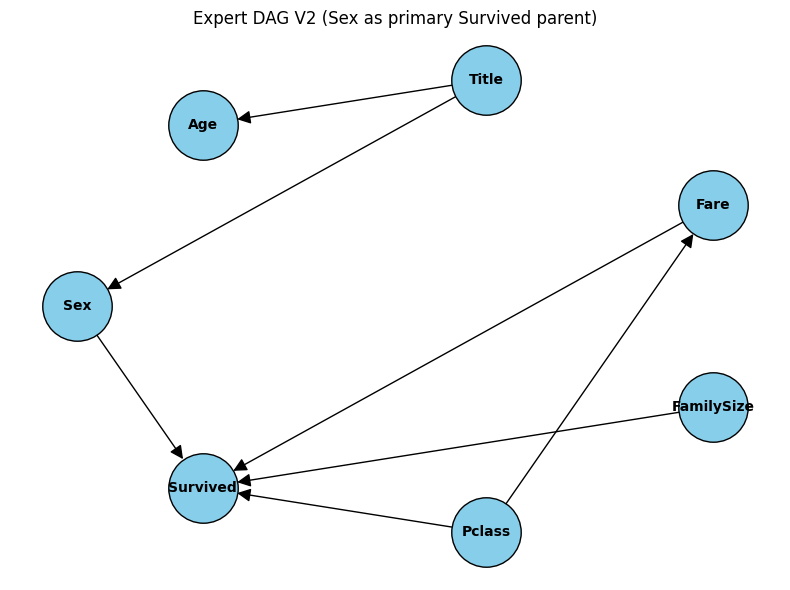

In [6]:
expert_edges_v2 = [
    ("Sex", "Survived"),
    ("Pclass", "Survived"),
    ("FamilySize", "Survived"),
    ("Fare", "Survived"),
    ("Pclass", "Fare"),
    ("Title", "Sex"),
    ("Title", "Age"),
]

# Visualize
fig, ax = plt.subplots(figsize=(8, 6))
G = nx.DiGraph(expert_edges_v2)
pos = nx.shell_layout(G)
nx.draw(
    G, pos, with_labels=True, node_color="skyblue", node_size=2500,
    font_size=10, font_weight="bold", arrowsize=20, ax=ax,
    edgecolors="black", linewidths=1,
)
ax.set_title("Expert DAG V2 (Sex as primary Survived parent)")
plt.tight_layout()
plt.show()

#### **5. Expert DAG + MLE**

In [7]:
expert_mle = DiscreteBayesianNetwork(expert_edges_v2)
expert_mle.fit(train_df, estimator=MaximumLikelihoodEstimator)

pred_expert_mle = expert_mle.predict(X_test_bn)
acc_expert_mle = accuracy_score(y_test, pred_expert_mle["Survived"].astype(int))
print(f"Expert DAG V2 + MLE accuracy: {acc_expert_mle:.2%}")

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Survived': 'C', 'Pclass': 'C', 'Sex': 'C', 'Age': 'C', 'Fare': 'C', 'FamilySize': 'C', 'Title': 'C'}


  0%|          | 0/44 [00:00<?, ?it/s]

Expert DAG V2 + MLE accuracy: 80.45%


#### **6. Expert DAG + BDeu (sweep equivalent_sample_size)**

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Survived': 'C', 'Pclass': 'C', 'Sex': 'C', 'Age': 'C', 'Fare': 'C', 'FamilySize': 'C', 'Title': 'C'}


  0%|          | 0/44 [00:00<?, ?it/s]

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Survived': 'C', 'Pclass': 'C', 'Sex': 'C', 'Age': 'C', 'Fare': 'C', 'FamilySize': 'C', 'Title': 'C'}


  ESS=  1 → 80.45%


  0%|          | 0/44 [00:00<?, ?it/s]

...

  0%|          | 0/44 [00:00<?, ?it/s]

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Survived': 'C', 'Pclass': 'C', 'Sex': 'C', 'Age': 'C', 'Fare': 'C', 'FamilySize': 'C', 'Title': 'C'}


  ESS= 50 → 80.45%


  0%|          | 0/44 [00:00<?, ?it/s]

  ESS=100 → 80.45%

Best ESS: 1 → 80.45%


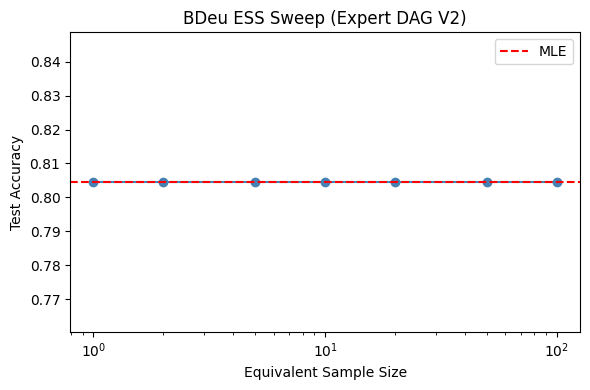

In [8]:
ess_values = [1, 2, 5, 10, 20, 50, 100]
ess_results = []

for ess in ess_values:
    model = DiscreteBayesianNetwork(expert_edges_v2)
    model.fit(
        train_df,
        estimator=BayesianEstimator,
        prior_type="BDeu",
        equivalent_sample_size=ess,
    )
    preds = model.predict(X_test_bn)
    acc = accuracy_score(y_test, preds["Survived"].astype(int))
    ess_results.append({"ESS": ess, "Accuracy": acc})
    print(f"  ESS={ess:>3d} → {acc:.2%}")

ess_df = pd.DataFrame(ess_results)
best_ess = ess_df.loc[ess_df["Accuracy"].idxmax()]
print(f"\nBest ESS: {int(best_ess['ESS'])} → {best_ess['Accuracy']:.2%}")

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ess_df["ESS"], ess_df["Accuracy"], "o-", color="steelblue")
ax.set_xlabel("Equivalent Sample Size")
ax.set_ylabel("Test Accuracy")
ax.set_title("BDeu ESS Sweep (Expert DAG V2)")
ax.set_xscale("log")
ax.axhline(acc_expert_mle, color="red", linestyle="--", label="MLE")
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
# Refit with best ESS for later comparison
best_ess_val = int(best_ess["ESS"])
expert_bayes = DiscreteBayesianNetwork(expert_edges_v2)
expert_bayes.fit(
    train_df,
    estimator=BayesianEstimator,
    prior_type="BDeu",
    equivalent_sample_size=best_ess_val,
)
pred_expert_bayes = expert_bayes.predict(X_test_bn)
acc_expert_bayes = accuracy_score(y_test, pred_expert_bayes["Survived"].astype(int))
print(f"Expert DAG V2 + BDeu (ESS={best_ess_val}): {acc_expert_bayes:.2%}")

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Survived': 'C', 'Pclass': 'C', 'Sex': 'C', 'Age': 'C', 'Fare': 'C', 'FamilySize': 'C', 'Title': 'C'}


  0%|          | 0/44 [00:00<?, ?it/s]

Expert DAG V2 + BDeu (ESS=1): 80.45%


### **7. Structure Learning (HillClimb + BIC)**

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Survived': 'C', 'Pclass': 'C', 'Sex': 'C', 'Age': 'C', 'Fare': 'C', 'FamilySize': 'C', 'Title': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Survived': 'C', 'Pclass': 'C', 'Sex': 'C', 'Age': 'C', 'Fare': 'C', 'FamilySize': 'C', 'Title': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Survived': 'C', 'Pclass': 'C', 'Sex': 'C', 'Age': 'C', 'Fare': 'C', 'FamilySize': 'C', 'Title': 'C'}


  0%|          | 0/1000000 [00:00<?, ?it/s]

Learned edges (HillClimb + BIC):
  Survived → Title
  Survived → FamilySize
  Pclass → Fare
  Pclass → Survived
  Pclass → Title
  FamilySize → Fare
  Title → Sex
  Title → Age
  Title → FamilySize


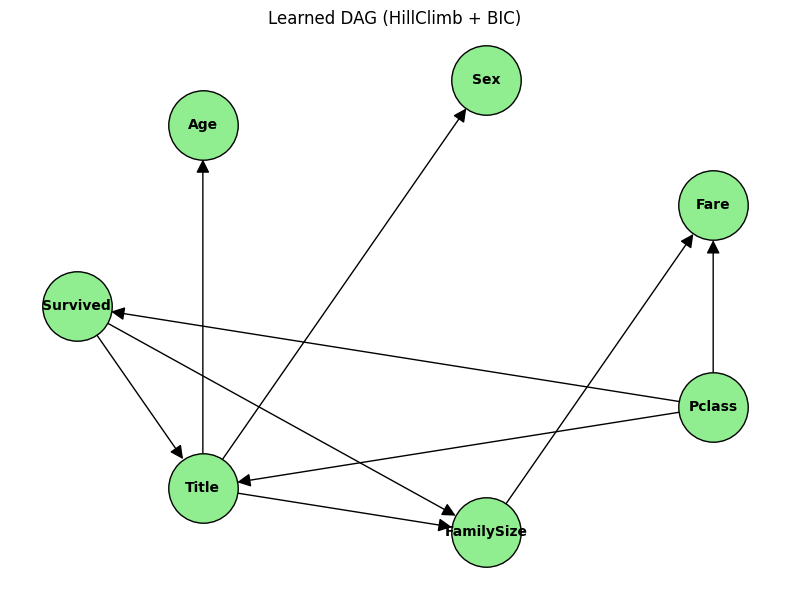

In [10]:
hc = HillClimbSearch(train_df)
learned_model = hc.estimate(scoring_method=BIC(train_df))
learned_edges = list(learned_model.edges())

print("Learned edges (HillClimb + BIC):")
for e in learned_edges:
    print(f"  {e[0]} → {e[1]}")

# Visualize
fig, ax = plt.subplots(figsize=(8, 6))
G_learned = nx.DiGraph(learned_edges)
pos_l = nx.shell_layout(G_learned)
nx.draw(
    G_learned, pos_l, with_labels=True, node_color="lightgreen", node_size=2500,
    font_size=10, font_weight="bold", arrowsize=20, ax=ax,
    edgecolors="black", linewidths=1,
)
ax.set_title("Learned DAG (HillClimb + BIC)")
plt.tight_layout()
plt.show()

In [11]:
# Fit learned structure with MLE
learned_bn = DiscreteBayesianNetwork(learned_edges)
learned_bn.fit(train_df, estimator=MaximumLikelihoodEstimator)

pred_learned = learned_bn.predict(X_test_bn)
acc_learned = accuracy_score(y_test, pred_learned["Survived"].astype(int))
print(f"Learned DAG + MLE accuracy: {acc_learned:.2%}")

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Survived': 'C', 'Pclass': 'C', 'Sex': 'C', 'Age': 'C', 'Fare': 'C', 'FamilySize': 'C', 'Title': 'C'}


  0%|          | 0/44 [00:00<?, ?it/s]

Learned DAG + MLE accuracy: 82.12%


In [12]:
# Fit learned structure with best BDeu
learned_bayes = DiscreteBayesianNetwork(learned_edges)
learned_bayes.fit(
    train_df,
    estimator=BayesianEstimator,
    prior_type="BDeu",
    equivalent_sample_size=best_ess_val,
)
pred_learned_bayes = learned_bayes.predict(X_test_bn)
acc_learned_bayes = accuracy_score(y_test, pred_learned_bayes["Survived"].astype(int))
print(f"Learned DAG + BDeu (ESS={best_ess_val}): {acc_learned_bayes:.2%}")

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Survived': 'C', 'Pclass': 'C', 'Sex': 'C', 'Age': 'C', 'Fare': 'C', 'FamilySize': 'C', 'Title': 'C'}


  0%|          | 0/44 [00:00<?, ?it/s]

Learned DAG + BDeu (ESS=1): 82.12%


#### **8. Tree-Augmented Naive Bayes (TAN)**

TAN adds exactly one inter-feature edge per feature on top of Naive Bayes.
This captures the strongest pairwise dependency without exploding CPT size.

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Survived': 'C', 'Pclass': 'C', 'Sex': 'C', 'Age': 'C', 'Fare': 'C', 'FamilySize': 'C', 'Title': 'C'}


Building tree:   0%|          | 0/21.0 [00:00<?, ?it/s]

TAN edges:
  Title → Sex
  Title → FamilySize
  Title → Age
  FamilySize → Fare
  Fare → Pclass
  Survived → Pclass
  Survived → Sex
  Survived → Age
  Survived → Fare
  Survived → FamilySize
  Survived → Title


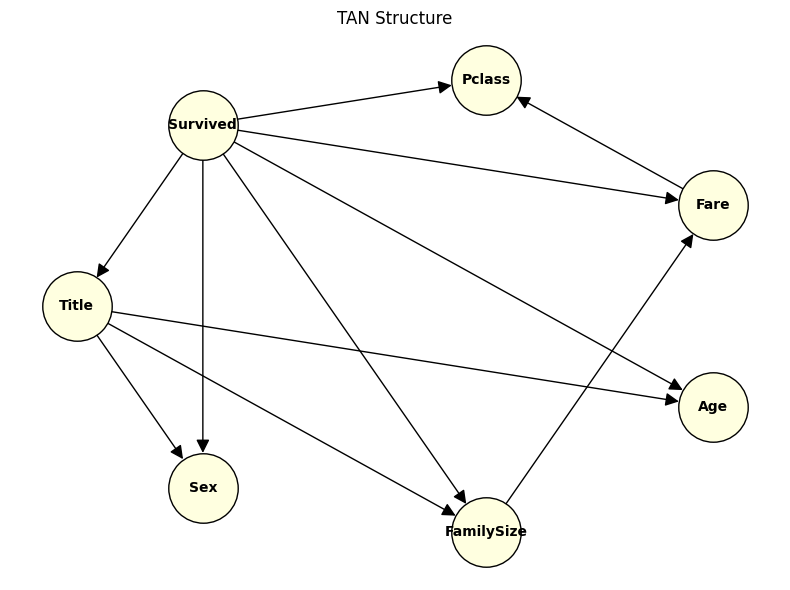

In [13]:
# TAN root_node must be a feature (not the class node).
# Use the feature with highest MI to Survived as root.
tan_search = TreeSearch(train_df, root_node="Title")
tan_model = tan_search.estimate(estimator_type="tan", class_node="Survived")
tan_edges = list(tan_model.edges())

print("TAN edges:")
for e in tan_edges:
    print(f"  {e[0]} → {e[1]}")

# Visualize
fig, ax = plt.subplots(figsize=(8, 6))
G_tan = nx.DiGraph(tan_edges)
pos_t = nx.shell_layout(G_tan)
nx.draw(
    G_tan, pos_t, with_labels=True, node_color="lightyellow", node_size=2500,
    font_size=10, font_weight="bold", arrowsize=20, ax=ax,
    edgecolors="black", linewidths=1,
)
ax.set_title("TAN Structure")
plt.tight_layout()
plt.show()

In [14]:
# TAN + MLE
tan_bn_mle = DiscreteBayesianNetwork(tan_edges)
tan_bn_mle.fit(train_df, estimator=MaximumLikelihoodEstimator)
pred_tan_mle = tan_bn_mle.predict(X_test_bn)
acc_tan_mle = accuracy_score(y_test, pred_tan_mle["Survived"].astype(int))
print(f"TAN + MLE accuracy: {acc_tan_mle:.2%}")

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Survived': 'C', 'Pclass': 'C', 'Sex': 'C', 'Age': 'C', 'Fare': 'C', 'FamilySize': 'C', 'Title': 'C'}


  0%|          | 0/44 [00:00<?, ?it/s]

TAN + MLE accuracy: 80.45%


In [15]:
# TAN + BDeu
tan_bn_bayes = DiscreteBayesianNetwork(tan_edges)
tan_bn_bayes.fit(
    train_df,
    estimator=BayesianEstimator,
    prior_type="BDeu",
    equivalent_sample_size=best_ess_val,
)
pred_tan_bayes = tan_bn_bayes.predict(X_test_bn)
acc_tan_bayes = accuracy_score(y_test, pred_tan_bayes["Survived"].astype(int))
print(f"TAN + BDeu (ESS={best_ess_val}): {acc_tan_bayes:.2%}")

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Survived': 'C', 'Pclass': 'C', 'Sex': 'C', 'Age': 'C', 'Fare': 'C', 'FamilySize': 'C', 'Title': 'C'}


  0%|          | 0/44 [00:00<?, ?it/s]

TAN + BDeu (ESS=1): 80.45%


#### **9. Decision Tree Baseline**

In [16]:
# Encode to numeric for Decision Tree
df_numeric = df.copy()
for col in df_numeric.columns:
    df_numeric[col] = df_numeric[col].astype("category").cat.codes

train_num, test_num = train_test_split(
    df_numeric, test_size=0.2, random_state=RANDOM_STATE, stratify=df_numeric["Survived"]
)
train_num = train_num.reset_index(drop=True)
test_num = test_num.reset_index(drop=True)

dt = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
dt.fit(train_num.drop(columns=["Survived"]), train_num["Survived"])
dt_preds = dt.predict(test_num.drop(columns=["Survived"]))
acc_dt = accuracy_score(test_num["Survived"], dt_preds)
print(f"Decision Tree (depth=5) accuracy: {acc_dt:.2%}")

Decision Tree (depth=5) accuracy: 81.01%


#### **10. Accuracy Comparison**

In [17]:
results = pd.DataFrame({
    "Model": [
        "Decision Tree (depth=5)",
        "BN Expert V2 + MLE",
        f"BN Expert V2 + BDeu (ESS={best_ess_val})",
        "BN Learned (HC+BIC) + MLE",
        f"BN Learned (HC+BIC) + BDeu (ESS={best_ess_val})",
        "BN TAN + MLE",
        f"BN TAN + BDeu (ESS={best_ess_val})",
    ],
    "Accuracy": [
        acc_dt,
        acc_expert_mle,
        acc_expert_bayes,
        acc_learned,
        acc_learned_bayes,
        acc_tan_mle,
        acc_tan_bayes,
    ],
})
results = results.sort_values("Accuracy", ascending=False).reset_index(drop=True)
results["Accuracy"] = results["Accuracy"].map("{:.2%}".format)
results

,Model,Accuracy
0,BN Learned (HC+BIC) + MLE,82.12%
1,BN Learned (HC+BIC) + BDeu (ESS=1),82.12%
2,Decision Tree (depth=5),81.01%
3,BN Expert V2 + BDeu (ESS=1),80.45%
4,BN Expert V2 + MLE,80.45%
5,BN TAN + MLE,80.45%
6,BN TAN + BDeu (ESS=1),80.45%


##### **11. Confusion Matrices**

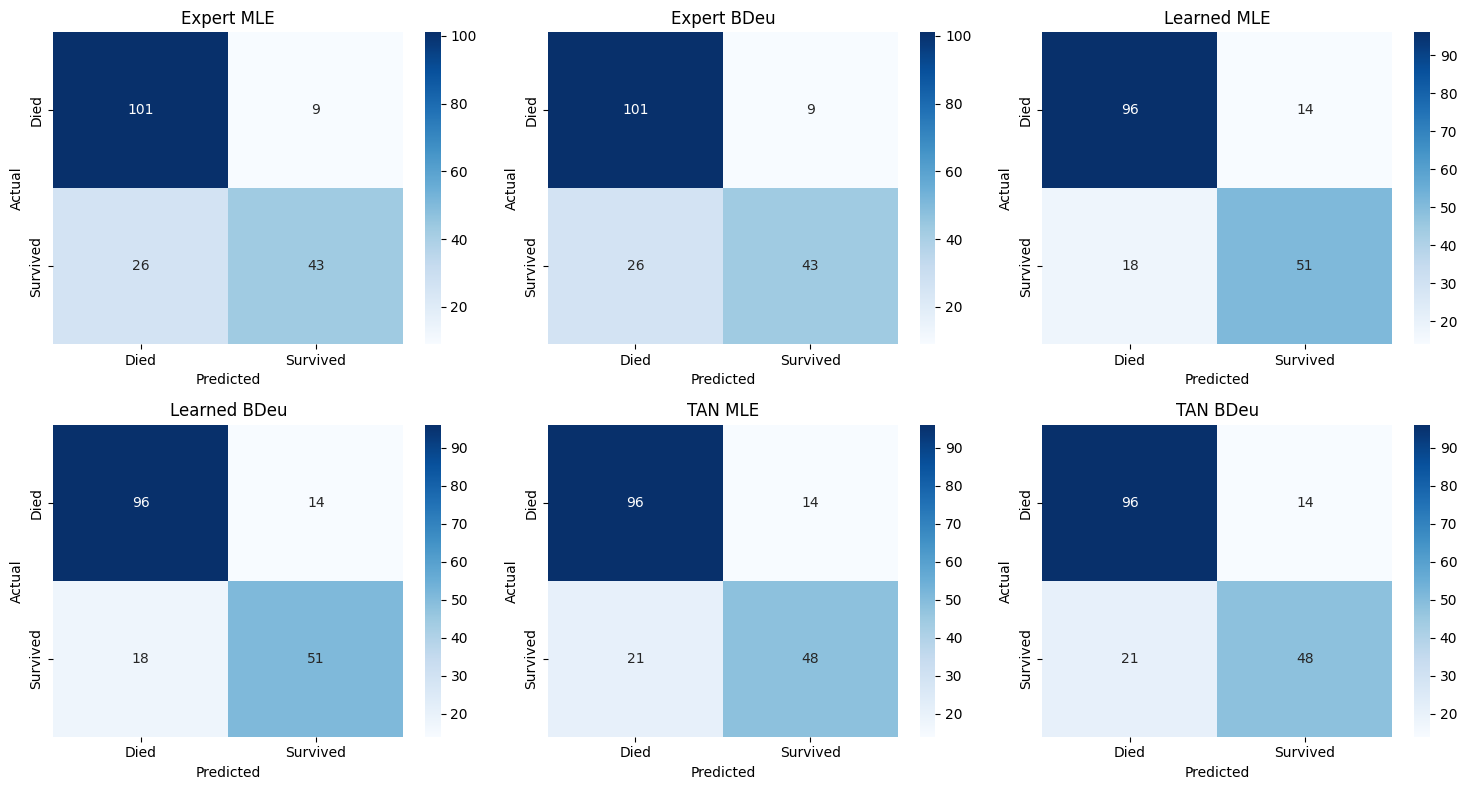

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

all_preds = [
    ("Expert MLE", pred_expert_mle["Survived"].astype(int)),
    ("Expert BDeu", pred_expert_bayes["Survived"].astype(int)),
    ("Learned MLE", pred_learned["Survived"].astype(int)),
    ("Learned BDeu", pred_learned_bayes["Survived"].astype(int)),
    ("TAN MLE", pred_tan_mle["Survived"].astype(int)),
    ("TAN BDeu", pred_tan_bayes["Survived"].astype(int)),
]

for ax, (name, preds) in zip(axes.flat, all_preds):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Died", "Survived"], yticklabels=["Died", "Survived"])
    ax.set_title(name)
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

plt.tight_layout()
plt.show()

In [19]:
# Classification reports for top models
for name, preds in all_preds:
    print(f"\n=== {name} ===")
    print(classification_report(y_test, preds, target_names=["Died", "Survived"]))


=== Expert MLE ===
              precision    recall  f1-score   support

        Died       0.80      0.92      0.85       110
    Survived       0.83      0.62      0.71        69

    accuracy                           0.80       179
   macro avg       0.81      0.77      0.78       179
weighted avg       0.81      0.80      0.80       179


=== Expert BDeu ===
              precision    recall  f1-score   support

        Died       0.80      0.92      0.85       110
    Survived       0.83      0.62      0.71        69

    accuracy                           0.80       179
   macro avg       0.81      0.77      0.78       179
weighted avg       0.81      0.80      0.80       179


=== Learned MLE ===
              precision    recall  f1-score   support

        Died       0.84      0.87      0.86       110
    Survived       0.78      0.74      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg

#### **12. DAG Comparison (side by side)**

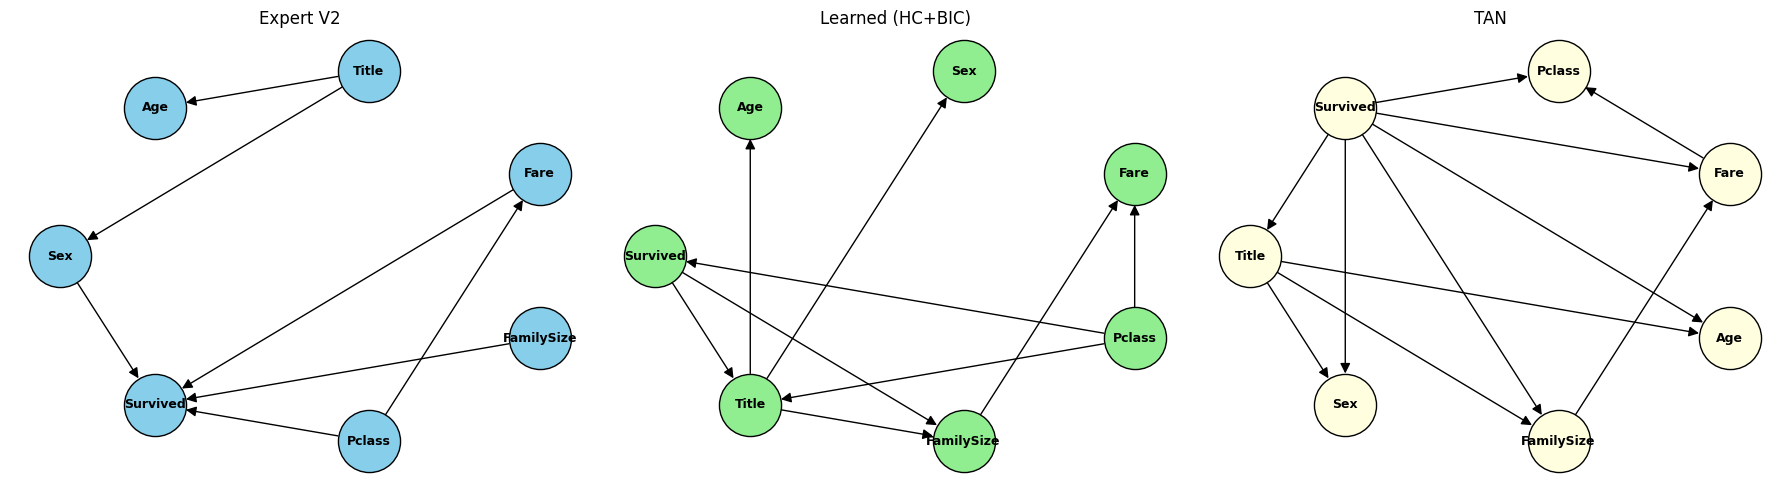

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

dags = [
    ("Expert V2", expert_edges_v2, "skyblue"),
    ("Learned (HC+BIC)", learned_edges, "lightgreen"),
    ("TAN", tan_edges, "lightyellow"),
]

for ax, (name, edges, color) in zip(axes, dags):
    G = nx.DiGraph(edges)
    pos = nx.shell_layout(G)
    nx.draw(
        G, pos, with_labels=True, node_color=color, node_size=2000,
        font_size=9, font_weight="bold", arrowsize=15, ax=ax,
        edgecolors="black", linewidths=1,
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

#### **13. Disagreement Analysis (Best BN vs Decision Tree)**

In [21]:
# Pick the best BN model's predictions
bn_accs = {
    "expert_mle": (acc_expert_mle, pred_expert_mle),
    "expert_bayes": (acc_expert_bayes, pred_expert_bayes),
    "learned_mle": (acc_learned, pred_learned),
    "learned_bayes": (acc_learned_bayes, pred_learned_bayes),
    "tan_mle": (acc_tan_mle, pred_tan_mle),
    "tan_bayes": (acc_tan_bayes, pred_tan_bayes),
}
best_name = max(bn_accs, key=lambda k: bn_accs[k][0])
best_acc, best_pred_df = bn_accs[best_name]
best_bn_preds = best_pred_df["Survived"].astype(int).values

print(f"Best BN model: {best_name} ({best_acc:.2%})")

disagree_mask = dt_preds != best_bn_preds
print(f"Disagreements: {disagree_mask.sum()} / {len(disagree_mask)} ({disagree_mask.mean():.1%})")

test_results = test_df.copy()
test_results["DT_Pred"] = dt_preds
test_results["BN_Pred"] = best_bn_preds
test_results["Actual"] = y_test.values

disagreement = test_results[test_results["DT_Pred"] != test_results["BN_Pred"]]

dt_right = (disagreement["DT_Pred"] == disagreement["Actual"]).sum()
bn_right = (disagreement["BN_Pred"] == disagreement["Actual"]).sum()
print(f"\nWhen they disagree:")
print(f"  DT correct: {dt_right} ({dt_right/len(disagreement):.1%})")
print(f"  BN correct: {bn_right} ({bn_right/len(disagreement):.1%})")

print("\nSample disagreements:")
disagreement.head(10)

Best BN model: learned_mle (82.12%)
Disagreements: 12 / 179 (6.7%)

When they disagree:
  DT correct: 5 (41.7%)
  BN correct: 7 (58.3%)

Sample disagreements:


,Survived,Pclass,Sex,Age,Fare,FamilySize,Title,DT_Pred,BN_Pred,Actual
4,1,3,female,Adult,High,Small,Miss,0,1,1
5,1,3,female,Adult,High,Small,Mrs,0,1,1
23,1,3,female,Adult,High,Small,Mrs,0,1,1
47,0,3,female,Adult,Low,Small,Mrs,0,1,0
60,0,3,female,Adult,High,Small,Mrs,0,1,0
65,0,3,female,Adult,High,Small,Miss,0,1,0
72,0,3,female,Adult,Low,Small,Miss,0,1,0
87,1,3,female,Adult,High,Small,Mrs,0,1,1
127,0,3,female,Adult,High,Small,Mrs,0,1,0
132,1,3,female,Adult,High,Small,Mrs,0,1,1


#### **Some Takeaways**

1. **Sex is irreplaceable as a direct predictor**: 2 categories = very dense CPTs. Replacing it with Title (5 categories) made accuracy worse despite Title encoding gender, because it fragmented the CPT.

2. **CPT density matters more than feature richness**: BNs with ~700 training rows need dense CPTs. Sex(2)×Pclass(3)×FamilySize(3)×Fare(2) = 36 cells ≈ 20 samples/cell is much better than 216 cells ≈ 3 samples/cell.

3. **Title works best as auxiliary signal**: Title→Sex and Title→Age edges encode domain knowledge without inflating Survived's CPT.

4. **BDeu smoothing**: The optimal `equivalent_sample_size` depends on CPT density. With dense CPTs (V2), the MLE vs BDeu difference is smaller.

5. **TAN structure**: Principled way to add one inter-feature dependency per feature beyond Naive Bayes, avoiding CPT explosion.

6. **Structure learning**: HillClimb + BIC discovers data-driven edges. Compare with expert DAG to validate domain assumptions.